# Data Loading & Inspection


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df = pd.read_csv('/content/restaurant_sales_data.csv')
df.head(10)

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
0,ORD_627866,CUST_009,Side Dishes,NaN,3,1,3.0,1/4/2022,Digital Wallet
1,ORD_767019,CUST_013,Main Dishes,Steak,20,4,80.0,5/7/2023,Cash
2,ORD_308031,CUST_093,Drinks,Water,1,3,3.0,7/29/2022,NaN
3,ORD_857952,CUST_069,Starters,Nachos Grande,10,5,50.0,1/21/2022,Credit Card
4,ORD_277814,CUST_074,Main Dishes,NaN,12,1,12.0,7/4/2022,NaN
5,ORD_600969,CUST_098,Desserts,NaN,6,-3,18.0,10/15/2023,NaN
6,ORD_445695,CUST_005,Starters,Sweet Potato Fries,5,1,5.0,8/10/2023,Cash
7,ORD_437294,CUST_065,STARTERS,Beef Chili,7,5,35.0,8/7/2023,Cash
8,ORD_515927,CUST_089,Desserts,Fruit Salad,-4,4,16.0,3/16/2023,Cash
9,ORD_280474,CUST_064,Drinks,Orange Juice,3,1,3.0,5/22/2023,Cash


In [102]:
df.tail()

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
8005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


removing all Null rows ( 3010 ) null

In [103]:
df.isna().all(axis=1).sum() # np.int64(3010)
df.dropna(how='all', inplace=True)



In [104]:
df.isna().all(axis=1).sum()

np.int64(0)

In [105]:
df.tail()

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
4995,ORD_939973,CUST_030,Starters,NaN,4.0$,1,4.0,11/18/2022,Credit Card
4996,ORD_279015,CUST_086,Drinks,Coca Cola,2.5,3,7.5,12/29/2023,Credit Card
4997,ORD_690423,CUST_011,Drinks,Iced Tea,2.5,NaN,2.5,10/11/2022,NaN
4998,ORD_210505,CUST_092,Desserts,NaN,6,3,NaN,6/9/2023,e-wallet
4999,ORD_167551,CUST_034,Main Dishes,NaN,NaN,NaN,NaN,6/16/2022,Digital Wallet


In [106]:
print(df.shape)
print(df.size)

(5000, 9)
45000


In [107]:
df.columns.to_list()

['Order ID',
 'Customer ID',
 'Category',
 'Item',
 'Price',
 'Quantity',
 'Order Total',
 'Order Date',
 'Payment Method']

In [108]:
df.dtypes
# Price , Quantity , Order date

,0
Order ID,object
Customer ID,object
Category,object
Item,object
Price,object
Quantity,object
Order Total,float64
Order Date,object
Payment Method,object


In [109]:
df.describe()

,Order Total
count,4687.000000
mean,19.993386
std,18.537430
min,1.000000
25%,8.000000
50%,15.000000
75%,25.000000
max,100.000000


In [110]:
df.describe(include='object')

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Date,Payment Method
count,5000,5000,5000,4261,4541,4632,4993,4370
unique,4996,100,22,26,42,20,735,16
top,ORD_180301,CUST_011,Main Dishes,Pasta Alfredo,5,3,8/7/2022,Cash
freq,2,65,963,286,862,910,18,1391


In [111]:
df.info()
# Price , Quantity , Order date >> dtype error
# item , price , quantity , order total , order date , pm >> null

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        5000 non-null   object 
 1   Customer ID     5000 non-null   object 
 2   Category        5000 non-null   object 
 3   Item            4261 non-null   object 
 4   Price           4541 non-null   object 
 5   Quantity        4632 non-null   object 
 6   Order Total     4687 non-null   float64
 7   Order Date      4993 non-null   object 
 8   Payment Method  4370 non-null   object 
dtypes: float64(1), object(8)
memory usage: 390.6+ KB


# Data cleaning

In [112]:
# checking dupl
df.duplicated().sum()

np.int64(4)

In [113]:
df[df.duplicated()]

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
1707,ORD_180301,CUST_028,Main Dishes,NaN,NaN,4,56.0,7/3/2022,Cash
3621,ORD_208235,CUST_027,Main Dishes,NaN,15,NaN,45.0,11/7/2023,Credit Card
4323,ORD_164641,CUST_090,Drinks,Water,1,5,5.0,10/5/2023,Credit Card
4674,ORD_729108,CUST_046,starters,Nachos Grande,10,2,20.0,4/18/2022,Credit Card


In [114]:
# check null
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,739
Price,459
Quantity,368
Order Total,313
Order Date,7
Payment Method,630


In [115]:
# check unique values in catigorual data

catcols = ['Category','Item','Payment Method']

for col in catcols:
    print(f'Column : {col}')
    print(df[col].unique())
    print('\n')


Column : Category
['Side Dishes' 'Main Dishes' 'Drinks' 'Starters' 'Desserts' 'STARTERS'
 'Main  Dishes' 'Main dishes' 'Starters ' 'DESSERTS' 'SIDE DISHES'
 ' Starters' 'side dishes' 'DRINKS' 'MAIN DISHES' 'desserts' 'drinks'
 'Side dishes' ' Desserts' 'Drinks ' 'main dishes' 'starters']


Column : Item
[nan 'Steak' 'Water' 'Nachos Grande' 'Sweet Potato Fries' 'Beef Chili'
 'Fruit Salad' 'Orange Juice' 'Grilled Chicken' 'Mashed Potatoes'
 'Pasta Alfredo' 'Garlic Bread' 'Cheese Fries' 'French Fries' 'Cheesecake'
 'Lemonade' 'Salmon' 'Side Salad' 'Grilled Vegetables' 'Chocolate Cake'
 'Chicken Melt' 'Iced Tea' 'Coca Cola' 'Vegetarian Platter' 'Onion Rings'
 'Ice Cream' 'Brownie']


Column : Payment Method
['Digital Wallet' 'Cash' nan 'Credit Card' 'CASH' 'Credit card '
 'Cash Payment' 'digital wallet' 'e-wallet' 'DIGITAL WALLET' 'CREDIT CARD'
 'creditcard' 'credit card' 'cash ' 'cash' ' Cash' ' Digital Wallet']




In [116]:
# check unique values in numerical data

numcols = ['Price','Quantity','Order Total']

for col in numcols:
    print(f'Column : {col}')
    print(df[col].unique())
    print('\n')

Column : Price
['3' '20' '1' '10' '12' '6' '5' '7' '-4' '15' '4' '18' nan '2.5' '6.0$'
 '8' '2.5$' '14' '10.0$' '1.0$' '14.0$' '7.0$' '4.0$' '12.0$' '-3' '18.0$'
 '3.0$' '-15' '20.0$' '5.0$' 'nan$' '15.0$' '-20' '-5' '-6' '-1' '-2.5'
 '-8' '8.0$' '-14' '-18' '-12' '-7']


Column : Quantity
['1' '4' '3' '5' '-3' '2' 'three' nan '4 items' '-1' '2 items' 'five'
 '3 items' '-4' '-2' '5 items' 'one' 'four' 'two' '-5' '1 items']


Column : Order Total
[  3.   80.   50.   12.   18.    5.   35.   16.   15.    8.   48.    4.
   nan  20.   21.   45.   60.   72.    6.   75.    2.   25.   10.   40.
   2.5  30.   36.   24.    1.   54.    9.   14.   28.   56.    7.5 100.
  70.   12.5   7.   90.   42.   32. ]




In [117]:
df['Order Date'].unique()

array(['1/4/2022', '5/7/2023', '7/29/2022', '1/21/2022', '7/4/2022',
       '10/15/2023', '8/10/2023', '8/7/2023', '3/16/2023', '5/22/2023',
       '1/29/2023', '1/27/2022', nan, '8/26/2023', '10/2/2022',
       '10/14/2022', '7/1/2022', '2/23/2022', '5/2/2023', '1/3/2023',
       '1/22/2022', '9/1/2023', '9/22/2023', '6/5/2023', '5/31/2023',
       '10/25/2023', '2/19/2022', '2/28/2022', '3/3/2022', '10/30/2022',
       '8/4/2022', '1/17/2023', '11/3/2022', '4/5/2023', '8/22/2022',
       '6/7/2023', '8/25/2022', '8/29/2022', '1/13/2023', '8/16/2022',
       '10/31/2022', '12/6/2023', '2/11/2023', '2/16/2022', '11/17/2022',
       '6/12/2023', '4/22/2023', '5/13/2022', '8/22/2023', '3/6/2022',
       '2/26/2023', '12/17/2022', '2/3/2023', '9/24/2023', '6/29/2022',
       '7/22/2023', '8/20/2023', '10/5/2023', '12/24/2022', '11/5/2022',
       '8/28/2022', '10/21/2022', '6/19/2022', '8/3/2023', '10/10/2023',
       '6/16/2023', '8/5/2022', '12/24/2023', '8/8/2022', '9/26/2022',
       

In [118]:
# Handling Duplicates

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# Categorail data


In [119]:
# handling strips and typos all ot once so we're left w real problems

df[catcols] = df[catcols].apply(lambda x  : x.str.strip())
df[catcols] = df[catcols].apply(lambda x  : x.str.title())

In [120]:
catcols = ['Category','Item','Payment Method']

for col in catcols:
    print(f'Column : {col}')
    print(df[col].unique())
    print('\n')


Column : Category
['Side Dishes' 'Main Dishes' 'Drinks' 'Starters' 'Desserts' 'Main  Dishes']


Column : Item
[nan 'Steak' 'Water' 'Nachos Grande' 'Sweet Potato Fries' 'Beef Chili'
 'Fruit Salad' 'Orange Juice' 'Grilled Chicken' 'Mashed Potatoes'
 'Pasta Alfredo' 'Garlic Bread' 'Cheese Fries' 'French Fries' 'Cheesecake'
 'Lemonade' 'Salmon' 'Side Salad' 'Grilled Vegetables' 'Chocolate Cake'
 'Chicken Melt' 'Iced Tea' 'Coca Cola' 'Vegetarian Platter' 'Onion Rings'
 'Ice Cream' 'Brownie']


Column : Payment Method
['Digital Wallet' 'Cash' nan 'Credit Card' 'Cash Payment' 'E-Wallet'
 'Creditcard']




In [121]:
df['Payment Method'] = df['Payment Method'].replace({
    'Cash Payment': 'Cash',
    'E-Wallet': 'Digital Wallet',
    'Creditcard': 'Credit Card'
})

df['Category'] = df['Category'].replace( 'Main  Dishes' , 'Main Dishes'
)

print(df['Payment Method'].unique() , '\n')
print(df['Category'].unique())

['Digital Wallet' 'Cash' nan 'Credit Card'] 

['Side Dishes' 'Main Dishes' 'Drinks' 'Starters' 'Desserts']


# Numerical data

In [122]:
# handling non-numercal errors all ot once so we're left w real problems

df[numcols] = df[numcols].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df[numcols] = df[numcols].abs()

In [123]:
numcols = ['Price','Quantity','Order Total']

for col in numcols:
    print(f'Column : {col}')
    print(df[col].unique())
    print('\n')

Column : Price
[ 3.  20.   1.  10.  12.   6.   5.   7.   4.  15.  18.   nan  2.5  8.
 14. ]


Column : Quantity
[ 1.  4.  3.  5.  2. nan]


Column : Order Total
[  3.   80.   50.   12.   18.    5.   35.   16.   15.    8.   48.    4.
   nan  20.   21.   45.   60.   72.    6.   75.    2.   25.   10.   40.
   2.5  30.   36.   24.    1.   54.    9.   14.   28.   56.    7.5 100.
  70.   12.5   7.   90.   42.   32. ]




# Handling null values

In [124]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,737
Price,570
Quantity,471
Order Total,313
Order Date,7
Payment Method,630


In [125]:
# catdata

# item by price
price_map = {
    1.0: 'Water',
    2.5: 'Iced Tea',
    3.0: 'Lemonade',
    4.0: 'French Fries',
    5.0: 'Ice Cream',
    6.0: 'Brownie',
    7.0: 'Beef Chili',
    8.0: 'Chicken Melt',
    10.0: 'Nachos Grande',
    12.0: 'Pasta Alfredo',
    14.0: 'Vegetarian Platter',
    15.0: 'Grilled Chicken',
    18.0: 'Salmon',
    20.0: 'Steak'
}

df['Item'] = df['Item'].fillna(df['Price'].map(price_map))


In [126]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,285
Price,570
Quantity,471
Order Total,313
Order Date,7
Payment Method,630


In [127]:
# Price map

price_map = {
    'Beef Chili': 7.0,
    'Brownie': 6.0,
    'Cheese Fries': 5.0,
    'Cheesecake': 7.0,
    'Chicken Melt': 8.0,
    'Chocolate Cake': 6.0,
    'Coca Cola': 2.5,
    'French Fries': 4.0,
    'Fruit Salad': 4.0,
    'Garlic Bread': 4.0,
    'Grilled Chicken': 15.0,
    'Grilled Vegetables': 5.0,
    'Ice Cream': 5.0,
    'Iced Tea': 2.5,
    'Lemonade': 3.0,
    'Mashed Potatoes': 4.0,
    'Nachos Grande': 10.0,
    'Onion Rings': 5.0,
    'Orange Juice': 3.0,
    'Pasta Alfredo': 12.0,
    'Salmon': 18.0,
    'Side Salad': 3.0,
    'Steak': 20.0,
    'Sweet Potato Fries': 5.0,
    'Vegetarian Platter': 14.0,
    'Water': 1.0
}

df['Price'] = df['Price'].fillna(df['Item'].map(price_map))


In [128]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,285
Price,285
Quantity,471
Order Total,313
Order Date,7
Payment Method,630


In [129]:
# dropping rows where the Price was missin >> item also
df = df.dropna(subset=['Price'])


In [130]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,0
Price,0
Quantity,339
Order Total,183
Order Date,7
Payment Method,527


In [131]:
# quantity by median >> median is less affected by outliers than the mean
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [132]:
#OT = p * q
df['Order Total'] = df['Order Total'].fillna(df['Price'] * df['Quantity'])

In [133]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,0
Price,0
Quantity,0
Order Total,0
Order Date,7
Payment Method,527


In [134]:
# fixing date
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4711 entries, 0 to 4998
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        4711 non-null   object        
 1   Customer ID     4711 non-null   object        
 2   Category        4711 non-null   object        
 3   Item            4711 non-null   object        
 4   Price           4711 non-null   float64       
 5   Quantity        4711 non-null   float64       
 6   Order Total     4711 non-null   float64       
 7   Order Date      4645 non-null   datetime64[ns]
 8   Payment Method  4184 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 368.0+ KB


In [135]:
# ffill
df['Order Date'].isnull().sum()
df['Order Date'] = df['Order Date'].fillna(method='ffill')

/tmp/ipykernel_8246/692539950.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Order Date'] = df['Order Date'].fillna(method='ffill')


In [136]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,0
Price,0
Quantity,0
Order Total,0
Order Date,0
Payment Method,527


In [137]:
df['Payment Method'].value_counts() #  527

,count
Payment Method,
Cash,1456
Credit Card,1374
Digital Wallet,1354


In [138]:
# by randomly adding pm to keep the % clean
null_count = df['Payment Method'].isna().sum()

df.loc[df['Payment Method'].isnull(), 'Payment Method'] = (
    df['Payment Method']
    .dropna()
    .sample(
        n=null_count,
        replace=True,
        weights=df['Payment Method'].dropna().map(
            df['Payment Method'].dropna().value_counts(normalize=True)
        ),
        random_state=42
    )
    .values
)

In [139]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,0
Price,0
Quantity,0
Order Total,0
Order Date,0
Payment Method,0


In [140]:
# checking for outliers

numcols = ['Price', 'Quantity', 'Order Total']

Q1 = df[numcols].quantile(0.25)
Q3 = df[numcols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df[numcols] < lower_bound) |
    (df[numcols] > upper_bound)
)

print('Price outlier')
print(upper_bound['Price'])
print(lower_bound['Price'])

print('\n\n')
print('Quantity outlier')
print(upper_bound['Quantity'])
print(lower_bound['Quantity'])

print('\n\n')
print('Order total outlier')
print(upper_bound['Order Total'])
print(lower_bound['Order Total'])

print('\n\n')
print("Number of outliers:")
print(outliers.sum())

Price outlier
13.0
-3.0



Quantity outlier
7.0
-1.0



Order total outlier
50.5
-17.5



Number of outliers:
Price          653
Quantity         0
Order Total    384
dtype: int64


In [141]:
df.loc[df['Price'].idxmax()]



,1
Order ID,ORD_767019
Customer ID,CUST_013
Category,Main Dishes
Item,Steak
Price,20.0
Quantity,4.0
Order Total,80.0
Order Date,2023-05-07 00:00:00
Payment Method,Cash


In [142]:
df.loc[df['Order Total'].idxmax()]

# The detected outliers are valid and represent realistic values,
# so they will not be removed.

,85
Order ID,ORD_629848
Customer ID,CUST_095
Category,Main Dishes
Item,Steak
Price,20.0
Quantity,5.0
Order Total,100.0
Order Date,2022-01-13 00:00:00
Payment Method,Credit Card


# groupby


In [143]:
# most repeated items

df.groupby('Item')['Quantity'].sum().sort_values(ascending=False)

,Quantity
Item,
Ice Cream,1022.0
Pasta Alfredo,994.0
French Fries,952.0
Water,865.0
Side Salad,802.0
Grilled Chicken,771.0
Mashed Potatoes,665.0
Chocolate Cake,650.0
Coca Cola,618.0


In [144]:
# most profitable item
df.groupby('Item')['Order Total'].sum().sort_values(ascending=False)

,Order Total
Item,
Pasta Alfredo,12060.0
Grilled Chicken,11655.0
Steak,9820.0
Salmon,6192.0
Ice Cream,5140.0
Vegetarian Platter,4648.0
French Fries,3876.0
Chocolate Cake,3840.0
Beef Chili,3220.0


In [145]:
# most profitable category

df.groupby('Category')['Order Total'].sum().sort_values(ascending=False)

,Order Total
Category,
Main Dishes,44375.0
Starters,16499.0
Desserts,15370.0
Side Dishes,11191.0
Drinks,6241.5


In [146]:
# most used payment method

df.groupby('Payment Method')['Order Total'].mean()

,Order Total
Payment Method,
Cash,20.605311
Credit Card,19.493191
Digital Wallet,19.494048


In [147]:
df['Day Name'] = df['Order Date'].dt.day_name()
df.groupby('Day Name')['Order Total'].sum().sort_values(ascending=False)

,Order Total
Day Name,
Sunday,14054.5
Tuesday,13781.5
Friday,13698.0
Monday,13684.0
Saturday,13622.0
Thursday,12958.5
Wednesday,11878.0


In [148]:
df['Customer Order Number'] = df.groupby('Customer ID').cumcount() + 1

In [149]:
df.columns

Index(['Order ID', 'Customer ID', 'Category', 'Item', 'Price', 'Quantity',
       'Order Total', 'Order Date', 'Payment Method', 'Day Name',
       'Customer Order Number'],
      dtype='object')

In [163]:
df.to_csv('Restaurant_Sales_Pandas_Project_cleaned.csv', index=False)
from google.colab import files

files.download('Restaurant_Sales_Pandas_Project_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

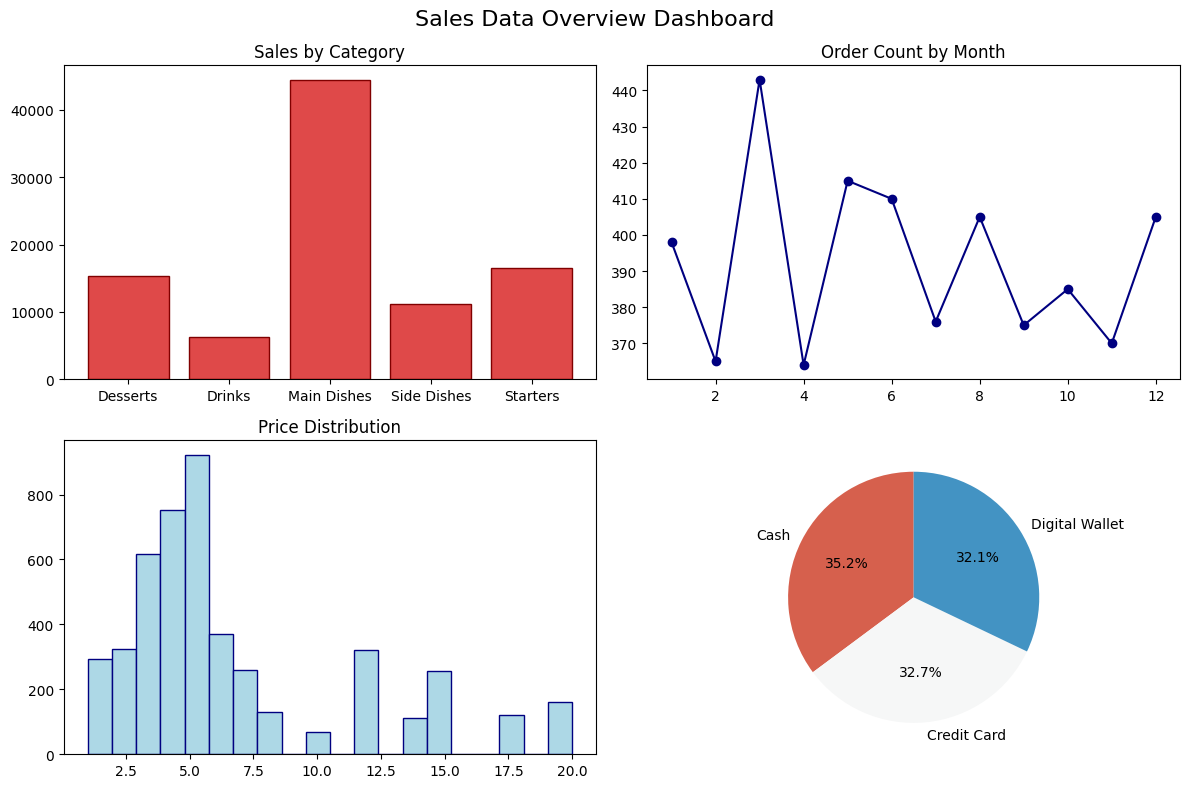

In [151]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle('Sales Data Overview Dashboard', fontsize=16)

sales_by_category = df.groupby('Category')['Order Total'].sum()
axes[0, 0].bar(
    sales_by_category.index,
    sales_by_category.values,
    color='#df4949',
    edgecolor='Maroon'
)
axes[0, 0].set_title('Sales by Category')


df['Order Date'] = pd.to_datetime(df['Order Date'])
orders_by_month = df.groupby(df['Order Date'].dt.month).size()
axes[0, 1].plot(
    orders_by_month.index,
    orders_by_month.values,
    marker='o',
    color='Navy',

)
axes[0, 1].set_title('Order Count by Month')

axes[1, 0].hist(df['Price'].dropna(), bins=20 , color='lightblue' , edgecolor='Navy')
axes[1, 0].set_title('Price Distribution')

payment_share = df['Payment Method'].value_counts()
colors = plt.cm.RdBu(
    np.linspace(0.2, 0.8, len(payment_share))
)
axes[1, 1].pie(
    payment_share.values,
    labels=payment_share.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)


plt.tight_layout()
plt.savefig('Sales Data Overview Dashboard.png', dpi=300, bbox_inches='tight')

plt.show()

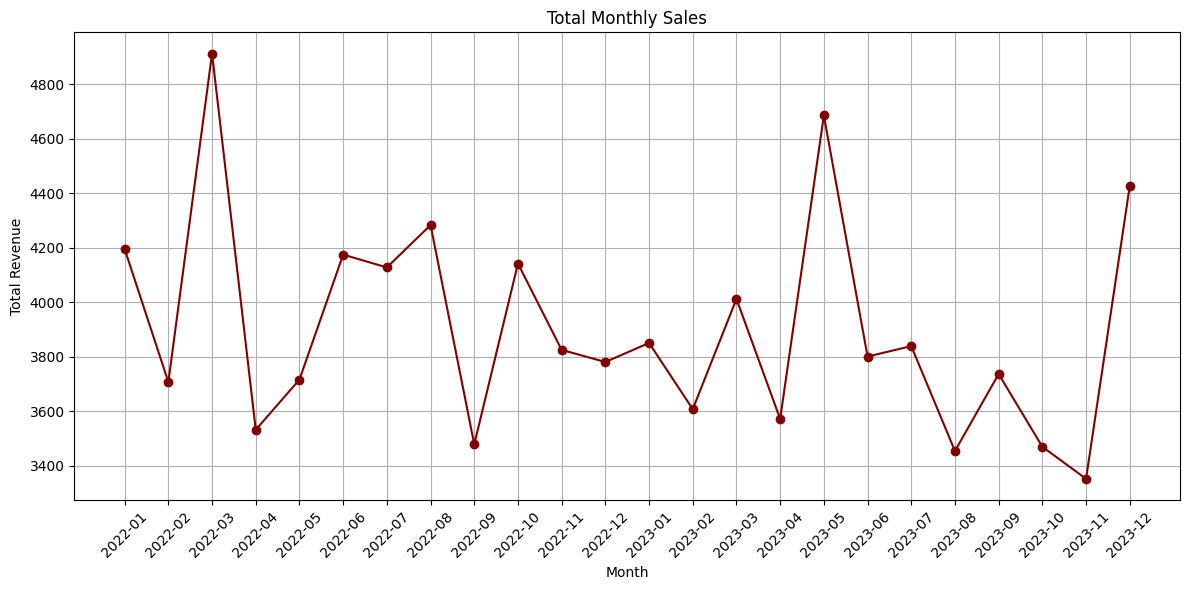

In [152]:
df['Year-Month'] = df['Order Date'].dt.to_period('M')
monthly_revenue = df.groupby('Year-Month')['Order Total'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str) # Prriod >> str
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o',
    linestyle='-',
    color = 'Maroon'
)

plt.title('Total Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.savefig('Total Monthly Sales.png', dpi=300, bbox_inches='tight')

plt.show()

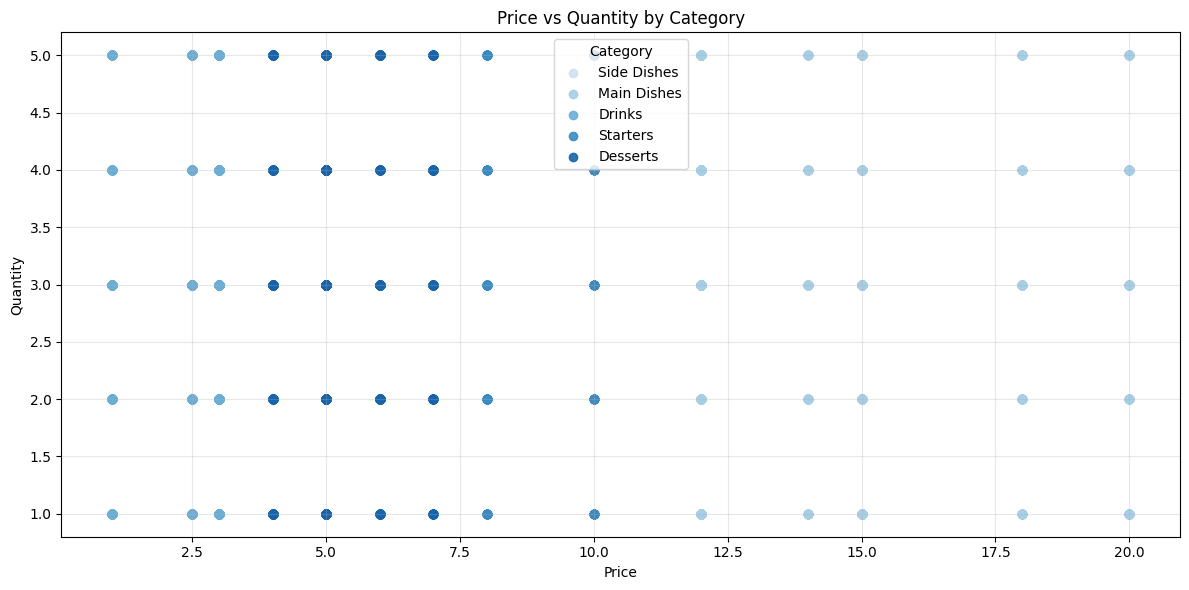

In [153]:
categories = df['Category'].dropna().unique()

colors = plt.cm.Blues(
    np.linspace(0.2, 0.8, len(categories))
)

plt.figure(figsize=(12, 6))

for category, color in zip(categories, colors):
    category_data = df[df['Category'] == category]

    plt.scatter(
        category_data['Price'],
        category_data['Quantity'],
        label=category,
        alpha=0.9,
        color=color
    )

plt.title('Price vs Quantity by Category')
plt.xlabel('Price')
plt.ylabel('Quantity')

plt.legend(title='Category')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Price vs Quantity by Category.png', dpi=300, bbox_inches='tight')

plt.show()

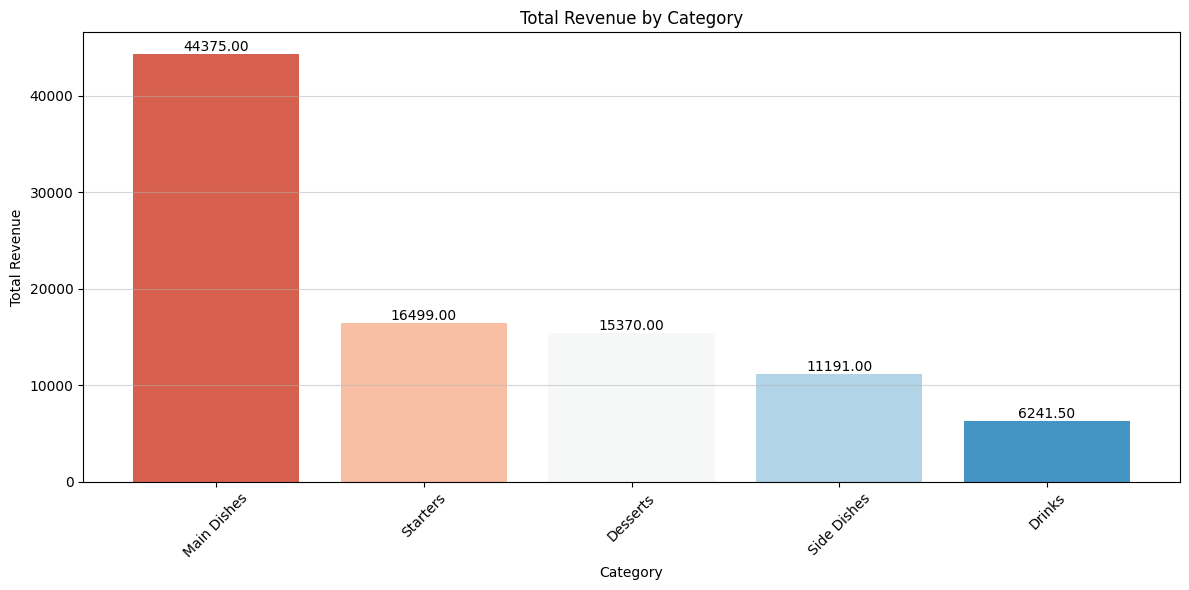

In [154]:
category_revenue = (
    df.groupby('Category')['Order Total']
    .sum()
    .sort_values(ascending=False)
)

colors = plt.cm.RdBu(
    np.linspace(0.2, 0.8, len(category_revenue))
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values,
    color=colors
)

plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )
plt.grid(True, axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Total Revenue by Category.png', dpi=300, bbox_inches='tight')

plt.show()

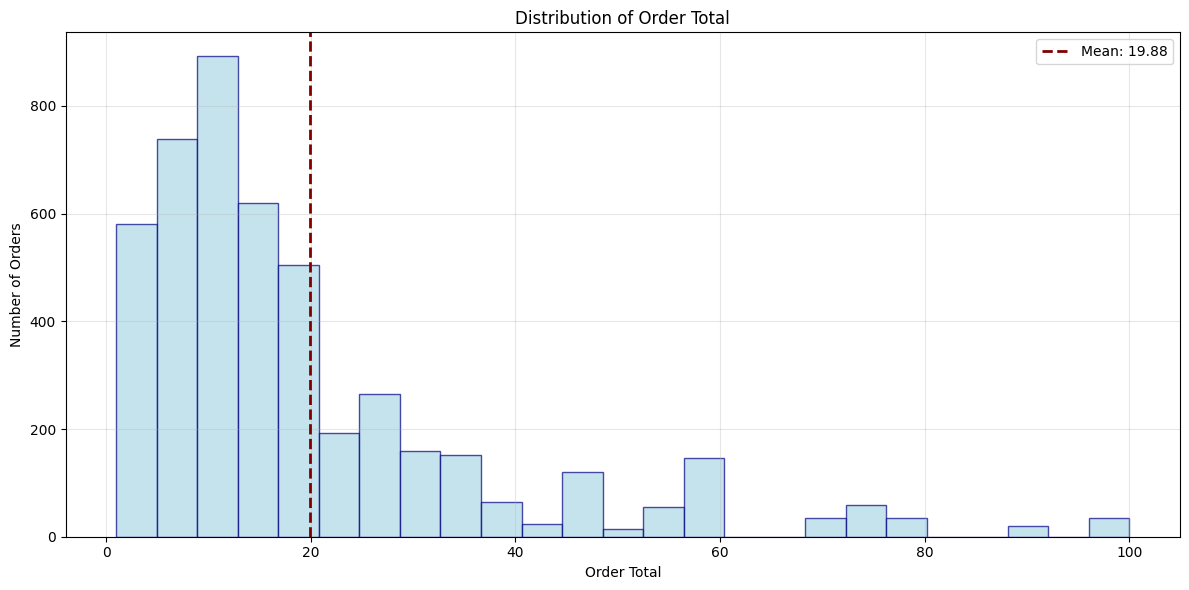

In [155]:

mean_order = df['Order Total'].mean()

plt.figure(figsize=(12, 6))


plt.hist(
    df['Order Total'],
    bins=25,
    edgecolor='Navy',
    color='lightblue',
    alpha=0.7
)


plt.axvline(
    mean_order,
    color='Maroon',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_order:.2f}'
)

plt.title('Distribution of Order Total')
plt.xlabel('Order Total')
plt.ylabel('Number of Orders')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Distribution of Order Total.png', dpi=300, bbox_inches='tight')

plt.show()

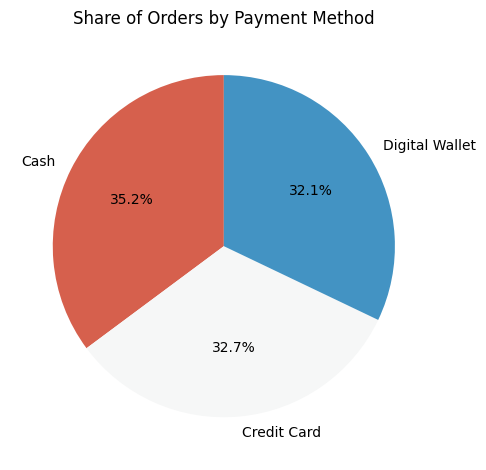

In [156]:

payment_counts = df['Payment Method'].value_counts()

colors = plt.cm.RdBu(
    np.linspace(0.2, 0.8, len(payment_share)))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Share of Orders by Payment Method')

plt.tight_layout()
plt.savefig('Share of Orders by Payment Method.png', dpi=300, bbox_inches='tight')

plt.show()

# extra


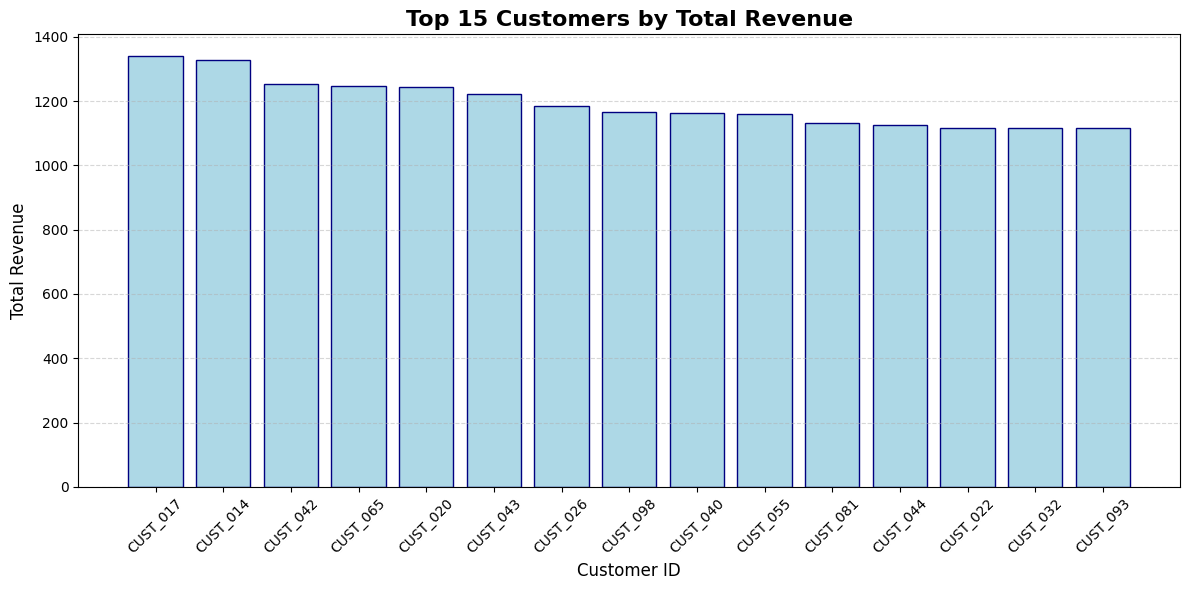

In [157]:
top_15_customers = (
    df.groupby('Customer ID')['Order Total']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_15_customers.index.astype(str),
    top_15_customers.values,
    color='Lightblue',
    edgecolor='Navy'
)

plt.title('Top 15 Customers by Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Top 15 Customers by Total Revenue.png', dpi=300, bbox_inches='tight')
plt.show()

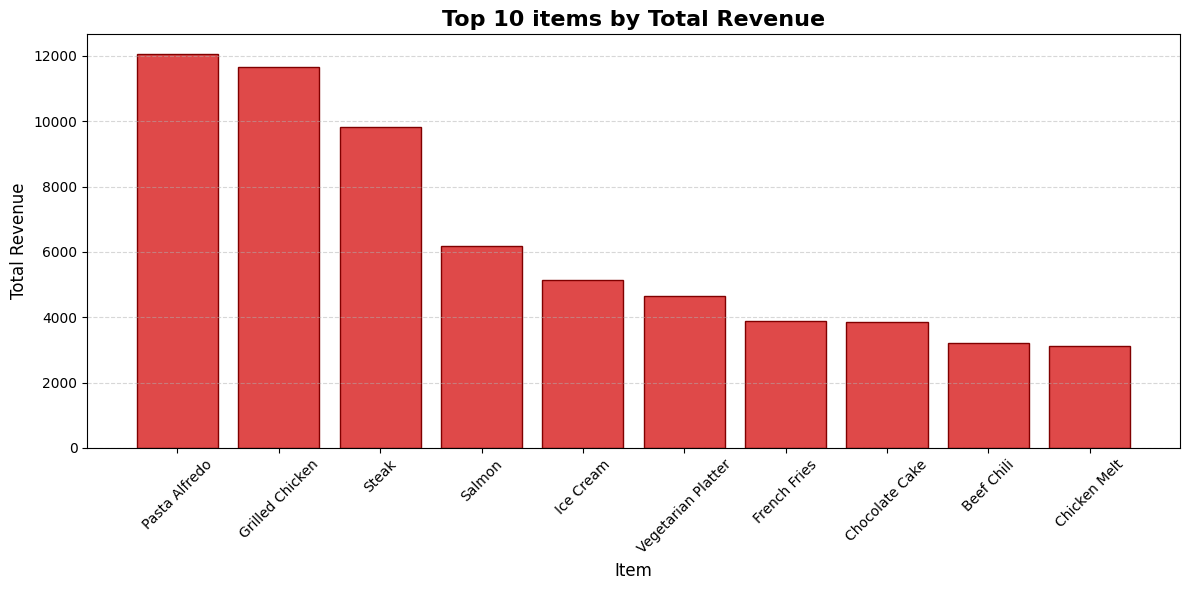

In [158]:
top_10_items = (
    df.groupby('Item')['Order Total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_items.index,
    top_10_items.values,
    color='#df4949',
    edgecolor='Maroon'
)

plt.title('Top 10 items by Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Item', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Top 10 Items by Total Revenue.png', dpi=300, bbox_inches='tight')

plt.show()

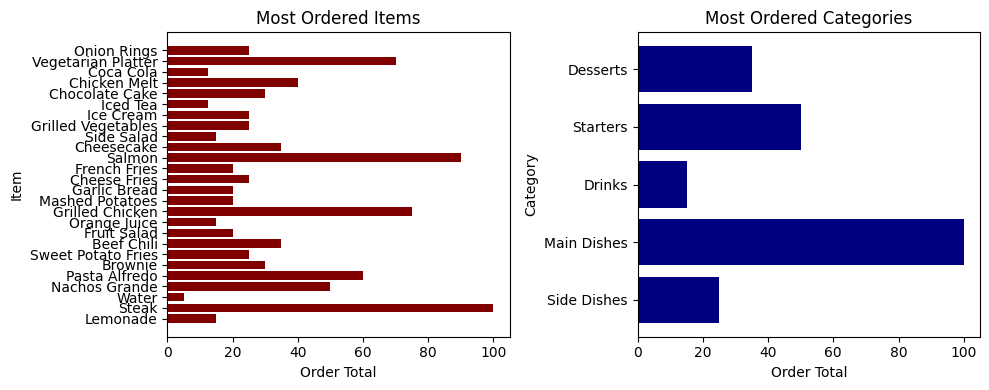

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].barh(df['Item'] , df['Order Total'] , color='Maroon')
axes[0].set_title('Most Ordered Items')
axes[0].set_xlabel("Order Total")
axes[0].set_ylabel("Item")

axes[1].barh(df['Category'] , df['Order Total'] , color='Navy')
axes[1].set_title('Most Ordered Categories')
axes[1].set_xlabel("Order Total")
axes[1].set_ylabel("Category")
plt.savefig('Most orderd.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

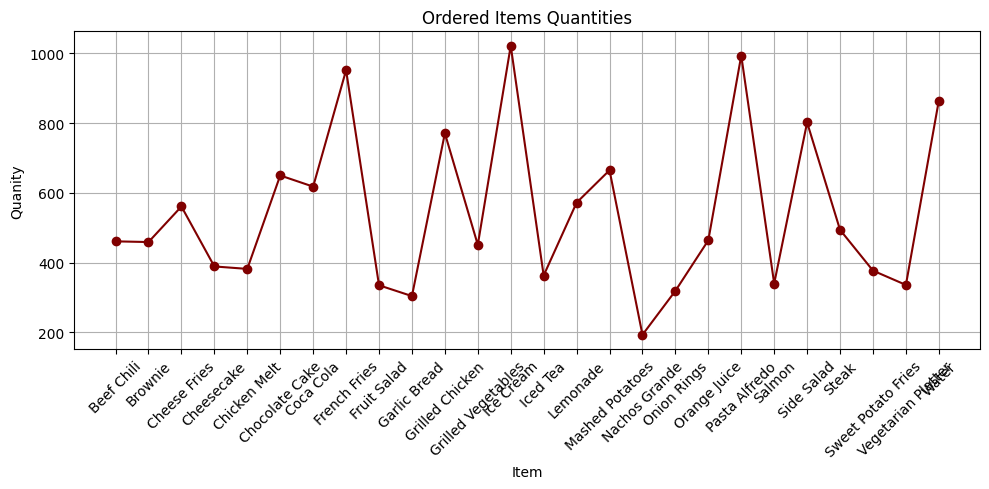

In [160]:
item_Quantities = df.groupby('Item')['Quantity'].sum().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(item_Quantities.index, item_Quantities.values, marker='o', linestyle='-', color='Maroon')
plt.title('Ordered Items Quantities')
plt.xlabel('Item')
plt.ylabel('Quanity')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Ordered Items Quantities.png', dpi=300, bbox_inches='tight')

plt.show()


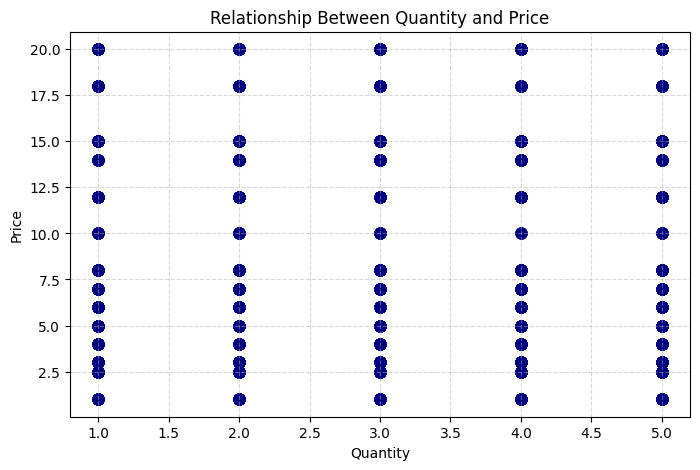

In [161]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['Price'], c='Navy', alpha=0.7, s=60)
plt.title('Relationship Between Quantity and Price')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('Relationship Between Quantity and Price.png', dpi=300, bbox_inches='tight')
plt.show()


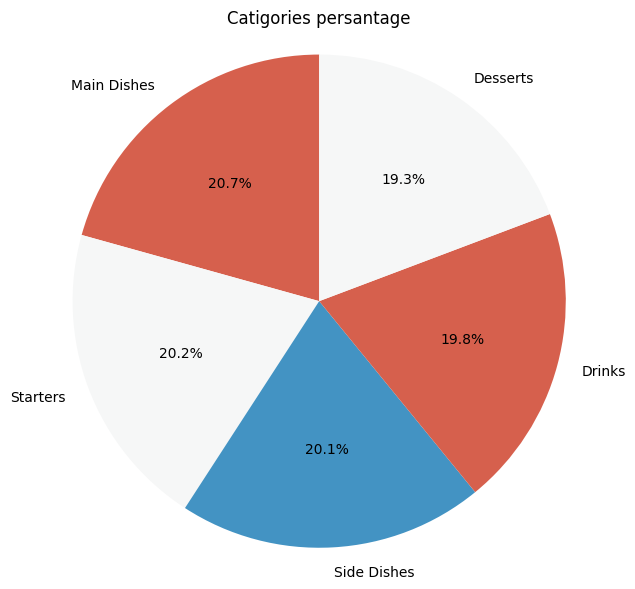

In [162]:
catshart = df['Category'].value_counts()
colors = plt.cm.RdBu(
    np.linspace(0.2, 0.8, len(payment_share)))
plt.figure(figsize=(7, 7))
plt.pie(catshart.values, labels=catshart.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
plt.title('Catigories persantage')
plt.axis('equal')  # keep the circle shape proportional
plt.savefig('Catigories persantage.png', dpi=300, bbox_inches='tight')
plt.show()

